<a href="https://colab.research.google.com/github/ZAJ44269/BrailleDecoderAlgorithm/blob/main/Modelos_entrenados_1_5_summary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
import os
import random
import shutil
import numpy as np
from PIL import Image
import cv2
import matplotlib.pyplot as plt

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from tensorflow.keras.models import load_model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
path = "/content/drive/MyDrive/ZAJ/PFC"

In [ ]:
clases=['letra_ _000000','letra_#_001111','letra_+_011010','letra_=_011011','letra_-_001001','letra_._001000','letra_a_100000','letra_b_110000','letra_c_100100','letra_d_100110','letra_e_100010','letra_f_110100','letra_g_110110','letra_h_110010','letra_i_010100','letra_j_010110','letra_l_111000','letra_m_101100','letra_n_101110','letra_ñ_110111','letra_o_101010','letra_p_111100','letra_q_111110','letra_r_111010','letra_s_011100','letra_t_011110','letra_u_101001','letra_v_111001','letra_w_010111','letra_y_101111','letra_z_101011']
len(clases)

In [ ]:
destino="/content/drive/My Drive/ZAJ/PFC/31_clases"

In [ ]:
def Grayscale_a_RGB(img):
    if img.ndim == 2:  # (H, W)
        img = np.stack((img,)*3, axis=-1)
    elif img.ndim == 3 and img.shape[2] == 1:
        img = np.concatenate([img]*3, axis=-1)

    #Resize (a 96x96)
    img = cv2.resize(img, (96, 96))
    return img.astype('float32')/255.0

##DATA AUGMENTATION

In [ ]:
datagen_train2 = ImageDataGenerator(
   validation_split=0.10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    shear_range=0.1,
    brightness_range=(0.3, 1.4),
    fill_mode='nearest',
    preprocessing_function=Grayscale_a_RGB
)

datagen_val2 = ImageDataGenerator(

    validation_split=0.10,
    preprocessing_function=Grayscale_a_RGB
)

train_gen2 = datagen_train2.flow_from_directory(
    destino,
    subset='training',
    target_size=(96, 96),
    batch_size=32,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=True
)

val_gen2 = datagen_val2.flow_from_directory(
    destino,
    subset='validation',
    target_size=(96, 96),
    batch_size=32,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False
)


Found 8191 images belonging to 31 classes.
Found 894 images belonging to 31 classes.


##Modelo 1

In [ ]:
base_model = MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(31, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)


model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,425,951 (9.25 MB)

 Trainable params: 167,967 (656.12 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Entrenamiento
history = model.fit(
    train_gen2,
    validation_data=val_gen2,
    epochs=60)

Epoch 1/60
256/256 ━━━━━━━━━━━━━━━━━━━━ 6219s 24s/step - accuracy: 0.3018 - loss: 2.4439 - val_accuracy: 0.5168 - val_loss: 1.5159
Epoch 2/60
256/256 ━━━━━━━━━━━━━━━━━━━━ 126s 493ms/step - accuracy: 0.5560 - loss: 1.5057 - val_accuracy: 0.6331 - val_loss: 1.0871
Epoch 3/60
256/256 ━━━━━━━━━━━━━━━━━━━━ 126s 493ms/step - accuracy: 0.6130 - loss: 1.2600 - val_accuracy: 0.6991 - val_loss: 0.8737
Epoch 4/60
256/256 ━━━━━━━━━━━━━━━━━━━━ 131s 512ms/step - accuracy: 0.6601 - loss: 1.0902 - val_accuracy: 0.7148 - val_loss: 0.8282
Epoch 5/60
256/256 ━━━━━━━━━━━━━━━━━━━━ 128s 498ms/step - accuracy: 0.6836 - loss: 1.0043 - val_accuracy: 0.7092 - val_loss: 0.8128
Epoch 6/60
256/256 ━━━━━━━━━━━━━━━━━━━━ 126s 492ms/step - accuracy: 0.7039 - loss: 0.9392 - val_accuracy: 0.6980 - val_loss: 0.8347
Epoch 7/60
256/256 ━━━━━━━━━━━━━━━━━━━━ 124s 486ms/step - accuracy: 0.7312 - loss: 0.8557 - val_accuracy: 0.7740 - val_loss: 0.6728
Epoch 8/60
256/256 ━━━━━━━━━━━━━━━━━━━━ 127s 495ms/step - accuracy: 0.7404 - 

28/28 ━━━━━━━━━━━━━━━━━━━━ 12s 391ms/step
                 precision    recall  f1-score   support

 letra_ _000000       1.00      1.00      1.00        29
 letra_#_001111       0.91      0.72      0.81        29
 letra_+_011010       0.96      0.86      0.91        29
 letra_-_001001       0.97      0.97      0.97        29
 letra_._001000       0.97      0.97      0.97        29
 letra_=_011011       0.97      1.00      0.98        29
 letra_a_100000       1.00      1.00      1.00        29
 letra_b_110000       0.97      0.97      0.97        29
 letra_c_100100       1.00      1.00      1.00        29
 letra_d_100110       0.72      0.79      0.75        29
 letra_e_100010       0.90      0.62      0.73        29
 letra_f_110100       0.79      0.66      0.72        29
 letra_g_110110       1.00      0.90      0.95        29
 letra_h_110010       0.73      0.76      0.75        29
 letra_i_010100       0.68      0.97      0.80        29
 letra_j_010110       0.82      0.67      0.7

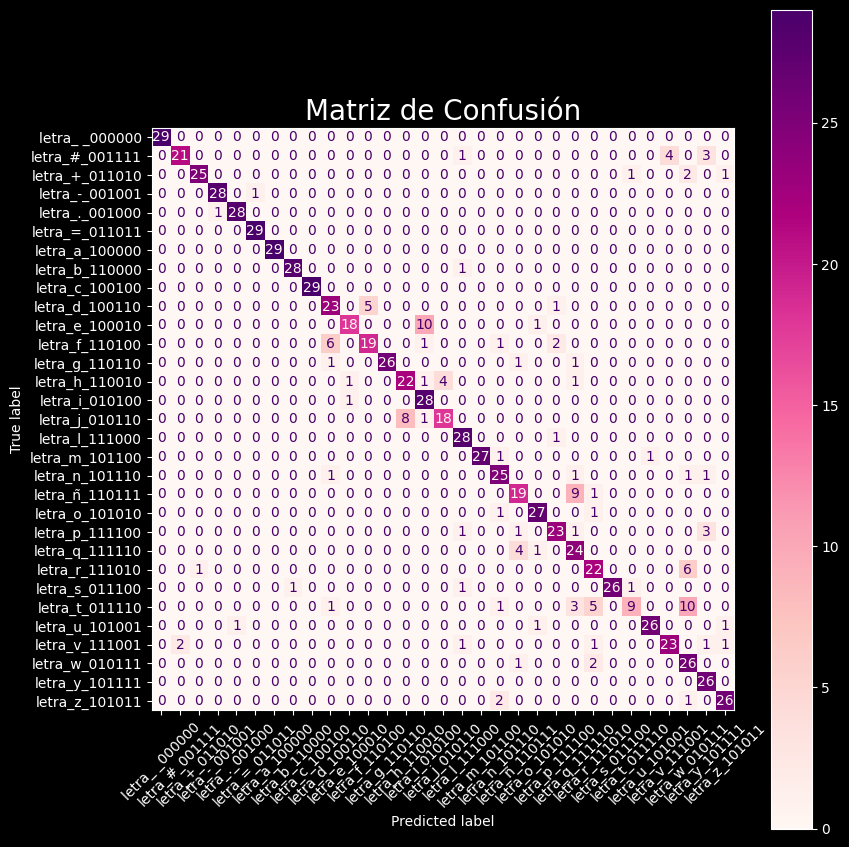

In [ ]:
val_gen2.reset()
y_pred_probs = model.predict(val_gen2, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)


y_true = val_gen2.classes
class_names = list(val_gen2.class_indices.keys())
print(classification_report(y_true, y_pred, target_names=class_names))


cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(9, 9))
disp.plot(ax=ax, cmap='RdPu', xticks_rotation=45, colorbar=True)
plt.title("Matriz de Confusión", fontsize=20)
plt.tight_layout()
plt.show()

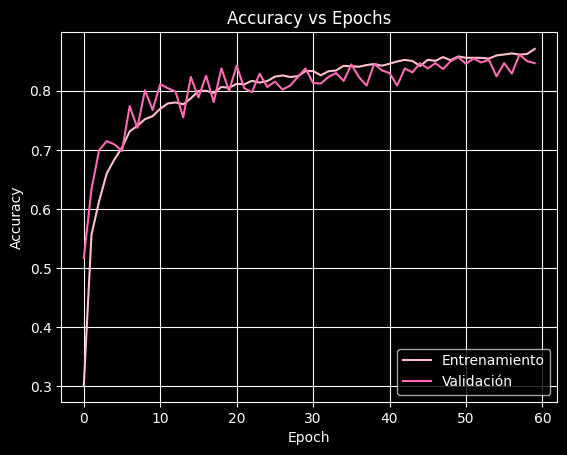

In [ ]:
# Accuracy
plt.figure()
plt.plot(history.history['accuracy'], label='Entrenamiento',color='pink')
plt.plot(history.history['val_accuracy'], label='Validación',color='hotpink')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epochs')
plt.legend()
plt.grid(True)
plt.show()

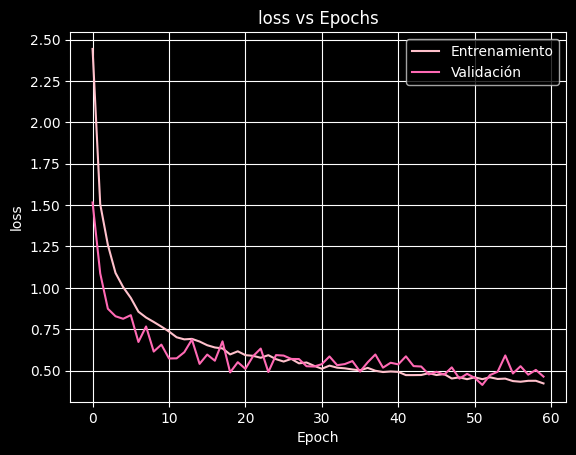

In [ ]:

plt.figure()
plt.plot(history.history['loss'], label='Entrenamiento',color='pink')
plt.plot(history.history['val_loss'], label='Validación',color='hotpink')
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.title('loss vs Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
model.save("/content/drive/MyDrive/ZAJ/PFC/Codigo/modelo-31 clases/modelo_braille_10_b.keras")

##Modelo 2


In [ ]:
base_model = MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x=Dense(256, activation='relu')(x)
x=Dropout(0.3)(x)
output = Dense(31, activation='softmax')(x)
model2 = Model(inputs=base_model.input, outputs=output)



model2.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,593,887 (9.89 MB)

 Trainable params: 335,903 (1.28 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model2.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
history2 = model2.fit(
    train_gen2,
    validation_data=val_gen2,
    epochs=60)

Epoch 1/60
256/256 ━━━━━━━━━━━━━━━━━━━━ 144s 518ms/step - accuracy: 0.2448 - loss: 2.6624 - val_accuracy: 0.5391 - val_loss: 1.5663
Epoch 2/60
256/256 ━━━━━━━━━━━━━━━━━━━━ 126s 491ms/step - accuracy: 0.4573 - loss: 1.7705 - val_accuracy: 0.6063 - val_loss: 1.2097
Epoch 3/60
256/256 ━━━━━━━━━━━━━━━━━━━━ 126s 491ms/step - accuracy: 0.5477 - loss: 1.4365 - val_accuracy: 0.6756 - val_loss: 0.9664
Epoch 4/60
256/256 ━━━━━━━━━━━━━━━━━━━━ 125s 489ms/step - accuracy: 0.5869 - loss: 1.2977 - val_accuracy: 0.7248 - val_loss: 0.8153
Epoch 5/60
256/256 ━━━━━━━━━━━━━━━━━━━━ 128s 499ms/step - accuracy: 0.6240 - loss: 1.1782 - val_accuracy: 0.7159 - val_loss: 0.7866
Epoch 6/60
256/256 ━━━━━━━━━━━━━━━━━━━━ 125s 490ms/step - accuracy: 0.6375 - loss: 1.1038 - val_accuracy: 0.7103 - val_loss: 0.7862
Epoch 7/60
256/256 ━━━━━━━━━━━━━━━━━━━━ 125s 486ms/step - accuracy: 0.6561 - loss: 1.0417 - val_accuracy: 0.7226 - val_loss: 0.7668
Epoch 8/60
256/256 ━━━━━━━━━━━━━━━━━━━━ 125s 489ms/step - accuracy: 0.6694 -

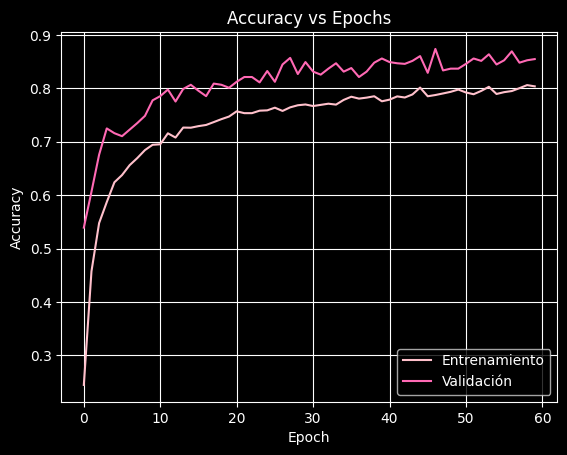

In [ ]:
# Accuracy
plt.figure()
plt.plot(history2.history['accuracy'], label='Entrenamiento',color='pink')
plt.plot(history2.history['val_accuracy'], label='Validación',color='hotpink')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epochs')
plt.legend()
plt.grid(True)
plt.show()

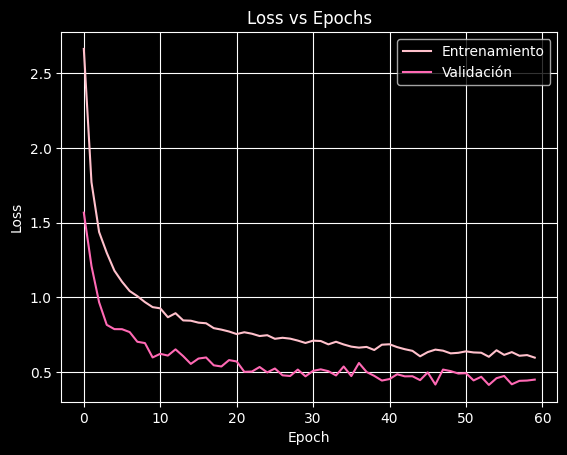

In [ ]:
# Accuracy
plt.figure()
plt.plot(history2.history['loss'], label='Entrenamiento',color='pink')
plt.plot(history2.history['val_loss'], label='Validación',color='hotpink')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.legend()
plt.grid(True)
plt.show()

28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 322ms/step
                 precision    recall  f1-score   support

 letra_ _000000       0.97      1.00      0.98        29
 letra_#_001111       0.78      0.86      0.82        29
 letra_+_011010       0.92      0.83      0.87        29
 letra_-_001001       1.00      0.97      0.98        29
 letra_._001000       0.94      1.00      0.97        29
 letra_=_011011       0.94      1.00      0.97        29
 letra_a_100000       1.00      1.00      1.00        29
 letra_b_110000       0.97      1.00      0.98        29
 letra_c_100100       0.97      1.00      0.98        29
 letra_d_100110       0.84      0.90      0.87        29
 letra_e_100010       0.72      0.72      0.72        29
 letra_f_110100       1.00      0.76      0.86        29
 letra_g_110110       0.96      0.90      0.93        29
 letra_h_110010       0.79      0.76      0.77        29
 letra_i_010100       0.75      0.83      0.79        29
 letra_j_010110       0.84      0.78      0.8

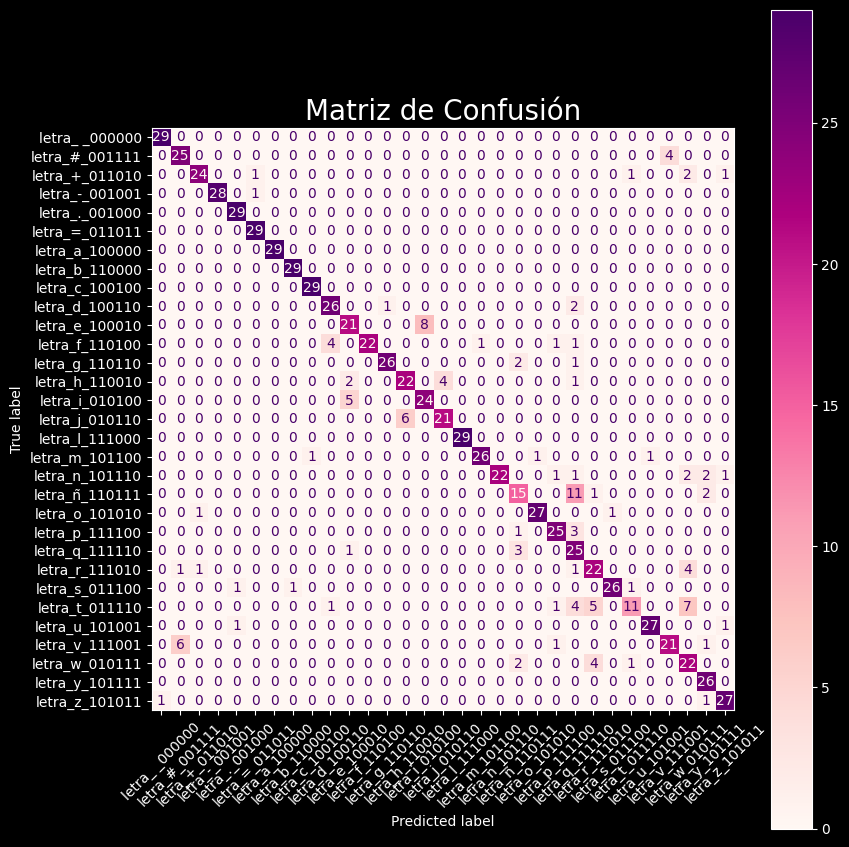

In [ ]:
val_gen2.reset()
y_pred_probs = model2.predict(val_gen2, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = val_gen2.classes
class_names = list(val_gen2.class_indices.keys())
print(classification_report(y_true, y_pred, target_names=class_names))


cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(9, 9))
disp.plot(ax=ax, cmap='RdPu', xticks_rotation=45, colorbar=True)
plt.title("Matriz de Confusión", fontsize=20)
plt.tight_layout()
plt.show()

##Modelo 3


In [ ]:
base_model6 = MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    weights='imagenet'
)
base_model6.trainable = False

x = base_model6.output
x = GlobalAveragePooling2D()(x)
x=Dense(256, activation='relu')(x)
x=Dropout(0.5)(x)
output = Dense(31, activation='softmax')(x)

model6 = Model(inputs=base_model6.input, outputs=output)



model6.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,593,887 (9.89 MB)

 Trainable params: 335,903 (1.28 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model6.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_tl = model6.fit(
    train_gen2,
    validation_data=val_gen2,
    epochs=30,
    batch_size=32
)


Epoch 1/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 3025s 12s/step - accuracy: 0.0922 - loss: 3.3824 - val_accuracy: 0.2584 - val_loss: 2.9186
Epoch 2/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 114s 447ms/step - accuracy: 0.1940 - loss: 2.9333 - val_accuracy: 0.3837 - val_loss: 2.4613
Epoch 3/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 112s 437ms/step - accuracy: 0.2600 - loss: 2.6371 - val_accuracy: 0.4362 - val_loss: 2.1234
Epoch 4/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 114s 444ms/step - accuracy: 0.3139 - loss: 2.4222 - val_accuracy: 0.5067 - val_loss: 1.8780
Epoch 5/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 113s 441ms/step - accuracy: 0.3501 - loss: 2.2344 - val_accuracy: 0.5313 - val_loss: 1.7050
Epoch 6/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 115s 450ms/step - accuracy: 0.3924 - loss: 2.0787 - val_accuracy: 0.5716 - val_loss: 1.5477
Epoch 7/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 113s 440ms/step - accuracy: 0.4192 - loss: 1.9617 - val_accuracy: 0.5951 - val_loss: 1.4333
Epoch 8/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 145s 452ms/step - accuracy: 0.4487 - 

In [ ]:
base_model6.trainable = True

for layer in base_model6.layers[:-30]:
    layer.trainable = False

In [ ]:
model6.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
history_ft = model6.fit(
    train_gen2,
    validation_data=val_gen2,
    epochs=30,
    batch_size=32
)


Epoch 1/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 163s 589ms/step - accuracy: 0.2978 - loss: 2.8144 - val_accuracy: 0.6700 - val_loss: 0.9476
Epoch 2/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 145s 565ms/step - accuracy: 0.4553 - loss: 1.7696 - val_accuracy: 0.6734 - val_loss: 0.9434
Epoch 3/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 146s 571ms/step - accuracy: 0.5295 - loss: 1.4615 - val_accuracy: 0.6745 - val_loss: 0.9146
Epoch 4/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 144s 562ms/step - accuracy: 0.5823 - loss: 1.2702 - val_accuracy: 0.7114 - val_loss: 0.8391
Epoch 5/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 146s 569ms/step - accuracy: 0.6179 - loss: 1.1366 - val_accuracy: 0.7405 - val_loss: 0.7701
Epoch 6/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 144s 563ms/step - accuracy: 0.6508 - loss: 1.0478 - val_accuracy: 0.7651 - val_loss: 0.6812
Epoch 7/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 145s 565ms/step - accuracy: 0.6853 - loss: 0.9617 - val_accuracy: 0.8188 - val_loss: 0.5851
Epoch 8/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 144s 562ms/step - accuracy: 0.7091 -

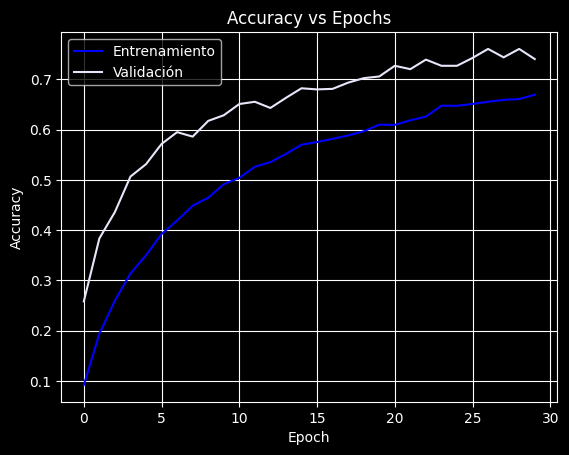

In [ ]:
# Accuracy
plt.figure()
plt.plot(history_tl.history['accuracy'], label='Entrenamiento',color='blue')
plt.plot(history_tl.history['val_accuracy'], label='Validación',color='lavender')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epochs')
plt.legend()
plt.grid(True)
plt.show()

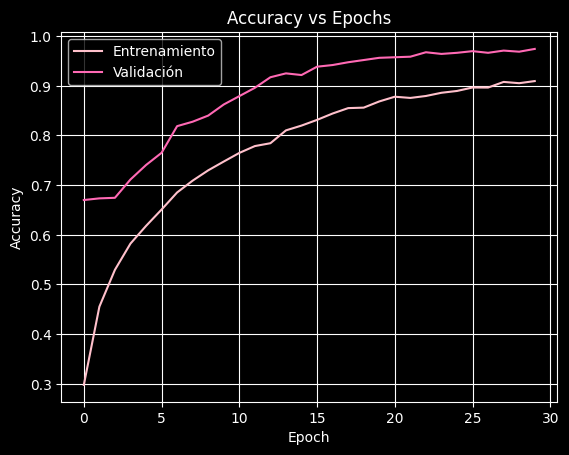

In [ ]:
# Accuracy
plt.figure()
plt.plot(history_ft.history['accuracy'], label='Entrenamiento',color='pink')
plt.plot(history_ft.history['val_accuracy'], label='Validación',color='hotpink')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epochs')
plt.legend()
plt.grid(True)
plt.show()

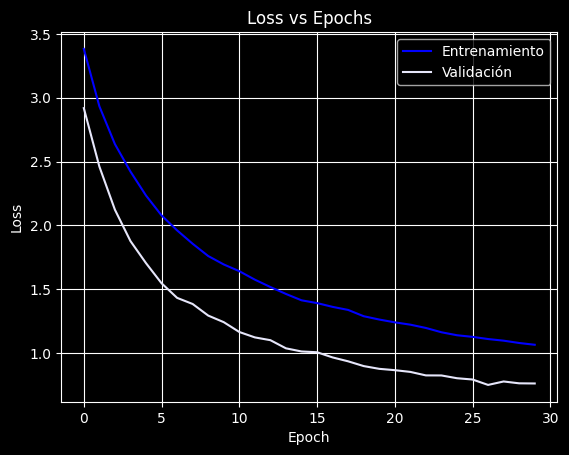

In [ ]:
# Accuracy
plt.figure()
plt.plot(history_tl.history['loss'], label='Entrenamiento',color='blue')
plt.plot(history_tl.history['val_loss'], label='Validación',color='lavender')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.legend()
plt.grid(True)
plt.show()

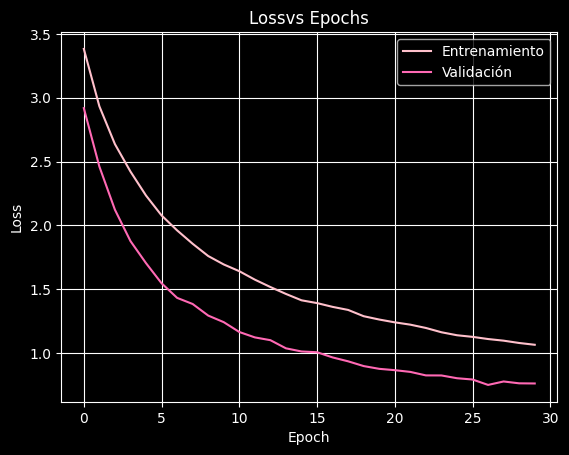

In [ ]:
# Accuracy
plt.figure()
plt.plot(history_tl.history['loss'], label='Entrenamiento',color='pink')
plt.plot(history_tl.history['val_loss'], label='Validación',color='hotpink')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Lossvs Epochs')
plt.legend()
plt.grid(True)
plt.show()

28/28 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step
                 precision    recall  f1-score   support

 letra_ _000000       0.97      0.97      0.97        29
 letra_#_001111       1.00      1.00      1.00        29
 letra_+_011010       1.00      0.93      0.96        29
 letra_-_001001       1.00      0.97      0.98        29
 letra_._001000       1.00      1.00      1.00        29
 letra_=_011011       0.94      1.00      0.97        29
 letra_a_100000       1.00      1.00      1.00        29
 letra_b_110000       0.94      1.00      0.97        29
 letra_c_100100       1.00      1.00      1.00        29
 letra_d_100110       0.94      1.00      0.97        29
 letra_e_100010       1.00      0.97      0.98        29
 letra_f_110100       1.00      0.97      0.98        29
 letra_g_110110       1.00      0.97      0.98        29
 letra_h_110010       0.97      1.00      0.98        29
 letra_i_010100       0.97      1.00      0.98        29
 letra_j_010110       1.00      0.96      0.98  

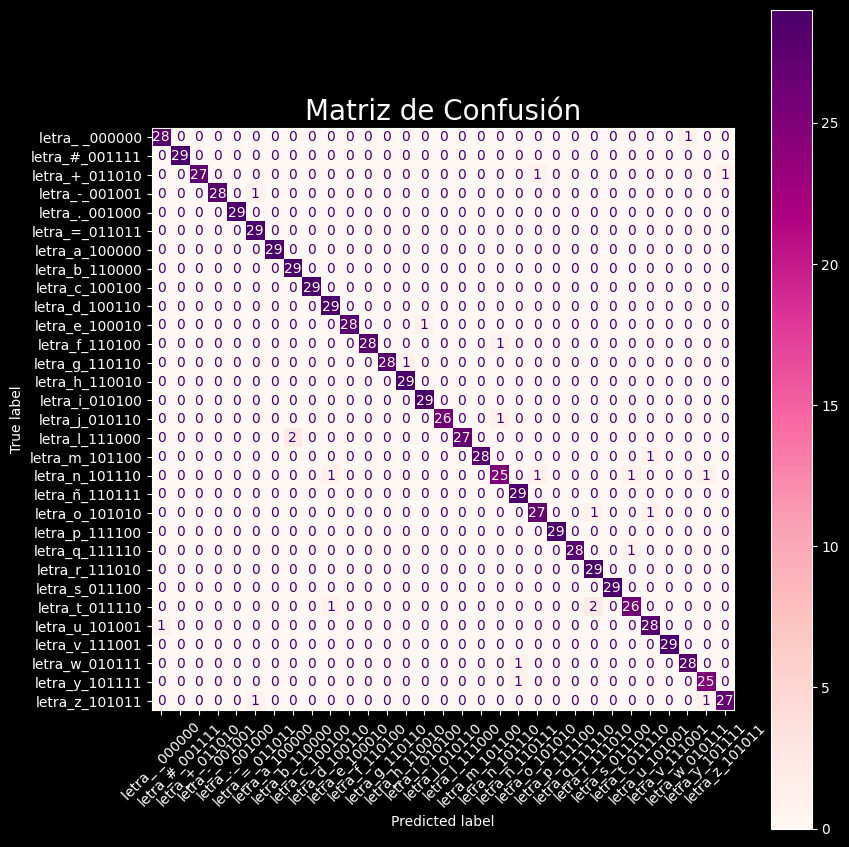

In [ ]:
val_gen2.reset()
y_pred_probs = model6.predict(val_gen2, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)


y_true = val_gen2.classes
class_names = list(val_gen2.class_indices.keys())
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(9, 9))
disp.plot(ax=ax, cmap='RdPu', xticks_rotation=45, colorbar=True)

plt.title("Matriz de Confusión", fontsize=20)
plt.tight_layout()
plt.show()

##Modelo 4


In [ ]:
base_model8 = MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    weights='imagenet'
)
base_model8.trainable = False

x = base_model8.output
x = GlobalAveragePooling2D()(x)
x=Dense(256, activation='relu')(x)
x=Dropout(0.3)(x)
output = Dense(31, activation='softmax')(x)

model8 = Model(inputs=base_model8.input, outputs=output)



model8.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,593,887 (9.89 MB)

 Trainable params: 335,903 (1.28 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model8.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_tl8 = model8.fit(
    train_gen2,
    validation_data=val_gen2,
    epochs=30,
    batch_size=32

)


Epoch 1/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 6121s 24s/step - accuracy: 0.1082 - loss: 3.3087 - val_accuracy: 0.2562 - val_loss: 2.8159
Epoch 2/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 130s 508ms/step - accuracy: 0.2366 - loss: 2.7740 - val_accuracy: 0.4105 - val_loss: 2.2852
Epoch 3/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 116s 455ms/step - accuracy: 0.3117 - loss: 2.4405 - val_accuracy: 0.4944 - val_loss: 1.9385
Epoch 4/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 117s 455ms/step - accuracy: 0.3852 - loss: 2.1710 - val_accuracy: 0.5134 - val_loss: 1.7090
Epoch 5/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 114s 445ms/step - accuracy: 0.4293 - loss: 1.9914 - val_accuracy: 0.5694 - val_loss: 1.5358
Epoch 6/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 121s 472ms/step - accuracy: 0.4584 - loss: 1.8690 - val_accuracy: 0.6085 - val_loss: 1.4051
Epoch 7/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 118s 461ms/step - accuracy: 0.4887 - loss: 1.7473 - val_accuracy: 0.6342 - val_loss: 1.2913
Epoch 8/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 119s 463ms/step - accuracy: 0.5098 - 

In [ ]:
base_model8.trainable = True
for layer in base_model8.layers[:-30]:
    layer.trainable = False

model8.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 3,265,695 (12.46 MB)

 Trainable params: 1,862,303 (7.10 MB)

 Non-trainable params: 731,584 (2.79 MB)

 Optimizer params: 671,808 (2.56 MB)

In [ ]:
model8.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
history_ft_8 = model8.fit(
    train_gen2,
    validation_data=val_gen2,
    epochs=40,
    batch_size=32
)


Epoch 1/40
256/256 ━━━━━━━━━━━━━━━━━━━━ 163s 586ms/step - accuracy: 0.3056 - loss: 2.8192 - val_accuracy: 0.6946 - val_loss: 0.8635
Epoch 2/40
256/256 ━━━━━━━━━━━━━━━━━━━━ 150s 583ms/step - accuracy: 0.4959 - loss: 1.6334 - val_accuracy: 0.6655 - val_loss: 0.9231
Epoch 3/40
256/256 ━━━━━━━━━━━━━━━━━━━━ 149s 581ms/step - accuracy: 0.5822 - loss: 1.3044 - val_accuracy: 0.6700 - val_loss: 0.9145
Epoch 4/40
256/256 ━━━━━━━━━━━━━━━━━━━━ 151s 591ms/step - accuracy: 0.6380 - loss: 1.1062 - val_accuracy: 0.6980 - val_loss: 0.8788
Epoch 5/40
256/256 ━━━━━━━━━━━━━━━━━━━━ 201s 586ms/step - accuracy: 0.6716 - loss: 0.9849 - val_accuracy: 0.7204 - val_loss: 0.7870
Epoch 6/40
256/256 ━━━━━━━━━━━━━━━━━━━━ 153s 597ms/step - accuracy: 0.7155 - loss: 0.8857 - val_accuracy: 0.7550 - val_loss: 0.6983
Epoch 7/40
256/256 ━━━━━━━━━━━━━━━━━━━━ 140s 547ms/step - accuracy: 0.7408 - loss: 0.8205 - val_accuracy: 0.7808 - val_loss: 0.6162
Epoch 8/40
256/256 ━━━━━━━━━━━━━━━━━━━━ 143s 559ms/step - accuracy: 0.7673 -

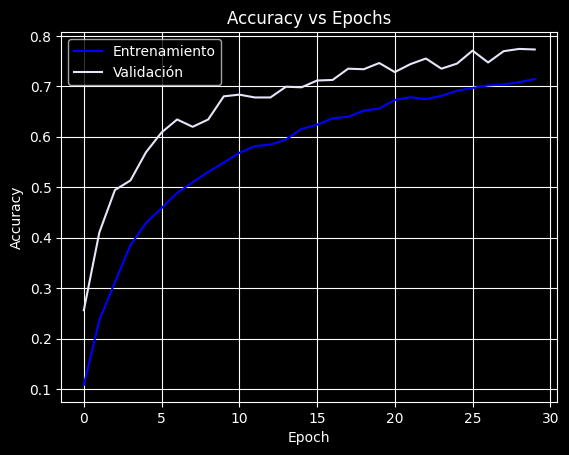

In [ ]:
# Accuracy
plt.figure()
plt.plot(history_tl8.history['accuracy'], label='Entrenamiento',color='blue')
plt.plot(history_tl8.history['val_accuracy'], label='Validación',color='lavender')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epochs')
plt.legend()
plt.grid(True)
plt.show()

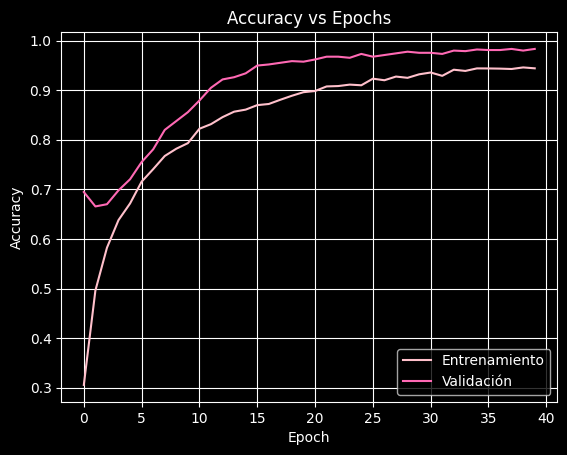

In [ ]:
# Accuracy
plt.figure()
plt.plot(history_ft_8.history['accuracy'], label='Entrenamiento',color='pink')
plt.plot(history_ft_8.history['val_accuracy'], label='Validación',color='hotpink')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epochs')
plt.legend()
plt.grid(True)
plt.show()

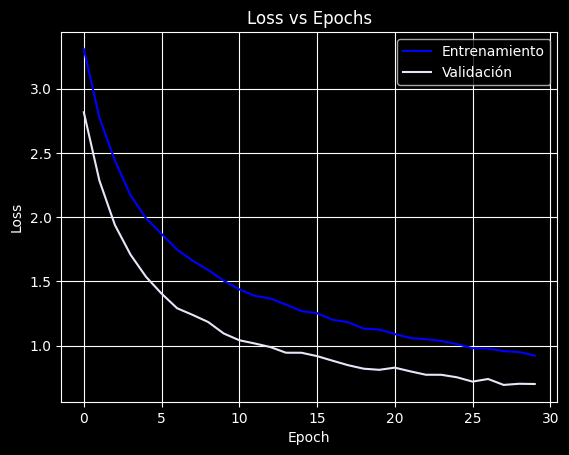

In [ ]:
# Accuracy
plt.figure()
plt.plot(history_tl8.history['loss'], label='Entrenamiento',color='blue')
plt.plot(history_tl8.history['val_loss'], label='Validación',color='lavender')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.legend()
plt.grid(True)
plt.show()

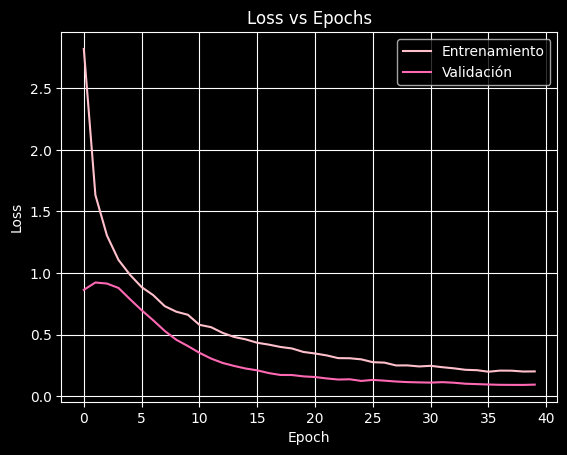

In [ ]:
# Accuracy
plt.figure()
plt.plot(history_ft_8.history['loss'], label='Entrenamiento',color='pink')
plt.plot(history_ft_8.history['val_loss'], label='Validación',color='hotpink')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.legend()
plt.grid(True)
plt.show()

28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 275ms/step
                 precision    recall  f1-score   support

 letra_ _000000       1.00      0.97      0.98        29
 letra_#_001111       1.00      1.00      1.00        29
 letra_+_011010       1.00      1.00      1.00        29
 letra_-_001001       1.00      0.93      0.96        29
 letra_._001000       0.94      1.00      0.97        29
 letra_=_011011       0.97      1.00      0.98        29
 letra_a_100000       0.97      1.00      0.98        29
 letra_b_110000       1.00      1.00      1.00        29
 letra_c_100100       1.00      1.00      1.00        29
 letra_d_100110       0.94      1.00      0.97        29
 letra_e_100010       1.00      1.00      1.00        29
 letra_f_110100       1.00      1.00      1.00        29
 letra_g_110110       1.00      1.00      1.00        29
 letra_h_110010       1.00      0.97      0.98        29
 letra_i_010100       1.00      1.00      1.00        29
 letra_j_010110       1.00      0.96      0.98

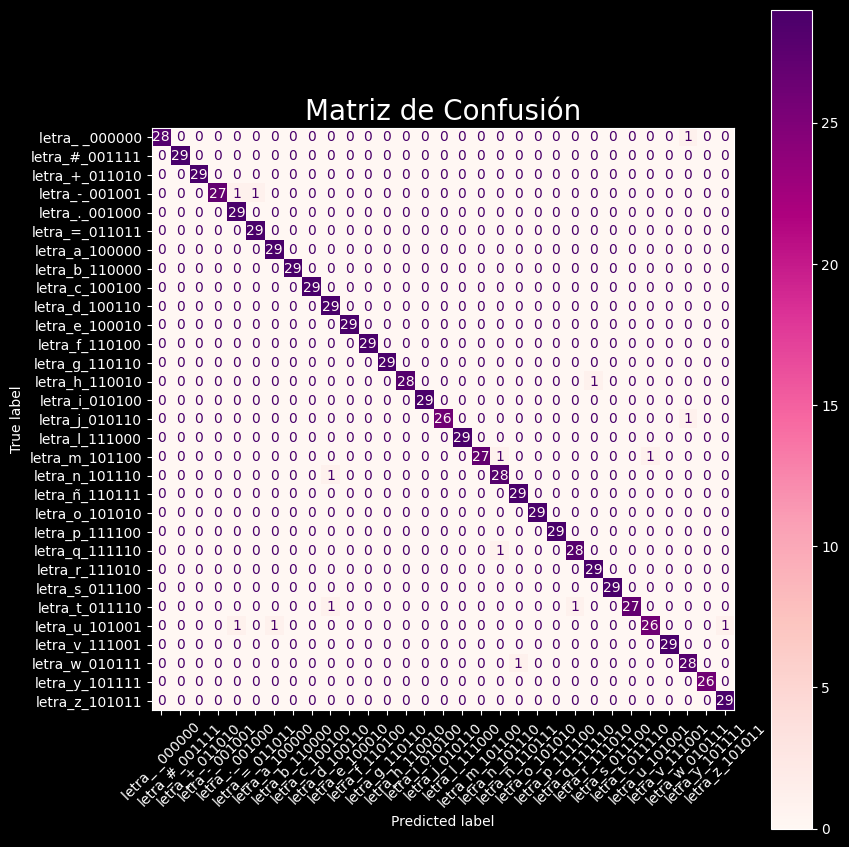

In [ ]:
val_gen2.reset()
y_pred_probs = model8.predict(val_gen2, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = val_gen2.classes
class_names = list(val_gen2.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_names))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(9, 9))
disp.plot(ax=ax, cmap='RdPu', xticks_rotation=45, colorbar=True)

plt.title("Matriz de Confusión", fontsize=20)
plt.tight_layout()
plt.show()

##Modelo 5


In [ ]:
base_model11 = MobileNetV2(
    input_shape=(96, 96, 3),
    alpha=0.75,
    include_top=False,
    weights='imagenet'
)
base_model11.trainable = False  # para transfer learning

x = base_model11.output
x = GlobalAveragePooling2D()(x)
x=Dense(256, activation='relu')(x)
x=Dropout(0.3)(x)
output = Dense(31, activation='softmax')(x)

model11 = Model(inputs=base_model11.input, outputs=output)

model11.summary()



Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        648 │ input_layer_7[0]… │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │         96 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        216 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │         96 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        384 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 1,717,967 (6.55 MB)

 Trainable params: 335,903 (1.28 MB)

 Non-trainable params: 1,382,064 (5.27 MB)

In [ ]:
model11.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_tl11 = model11.fit(
    train_gen2,
    validation_data=val_gen2,
    epochs=30,
    batch_size=32
)


Epoch 1/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 2230s 9s/step - accuracy: 0.1194 - loss: 3.2318 - val_accuracy: 0.3087 - val_loss: 2.6772
Epoch 2/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 120s 469ms/step - accuracy: 0.2493 - loss: 2.6735 - val_accuracy: 0.4306 - val_loss: 2.1381
Epoch 3/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 122s 477ms/step - accuracy: 0.3381 - loss: 2.3312 - val_accuracy: 0.5190 - val_loss: 1.7865
Epoch 4/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 118s 460ms/step - accuracy: 0.3943 - loss: 2.1077 - val_accuracy: 0.5984 - val_loss: 1.5312
Epoch 5/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 116s 454ms/step - accuracy: 0.4311 - loss: 1.9396 - val_accuracy: 0.6633 - val_loss: 1.3441
Epoch 6/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 119s 462ms/step - accuracy: 0.4754 - loss: 1.7926 - val_accuracy: 0.6868 - val_loss: 1.2379
Epoch 7/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 115s 448ms/step - accuracy: 0.4951 - loss: 1.6956 - val_accuracy: 0.7159 - val_loss: 1.1217
Epoch 8/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 119s 463ms/step - accuracy: 0.5214 - l

In [ ]:
base_model11.trainable = True

for layer in base_model11.layers[:-30]:
    layer.trainable = False


model11.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        648 │ input_layer_6[0]… │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │         96 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        216 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │         96 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        384 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 1,717,967 (6.55 MB)

 Trainable params: 1,279,743 (4.88 MB)

 Non-trainable params: 438,224 (1.67 MB)

In [ ]:
model11.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
history_ft_11= model11.fit(
    train_gen2,
    validation_data=val_gen2,
    epochs=60,
    batch_size=32
)


Epoch 1/60
256/256 ━━━━━━━━━━━━━━━━━━━━ 151s 584ms/step - accuracy: 0.4832 - loss: 1.7227 - val_accuracy: 0.6465 - val_loss: 1.0763
Epoch 2/60
256/256 ━━━━━━━━━━━━━━━━━━━━ 139s 543ms/step - accuracy: 0.5673 - loss: 1.3743 - val_accuracy: 0.6600 - val_loss: 0.9838
Epoch 3/60
256/256 ━━━━━━━━━━━━━━━━━━━━ 136s 533ms/step - accuracy: 0.6169 - loss: 1.2133 - val_accuracy: 0.7181 - val_loss: 0.7998
Epoch 4/60
256/256 ━━━━━━━━━━━━━━━━━━━━ 140s 524ms/step - accuracy: 0.6484 - loss: 1.0935 - val_accuracy: 0.7539 - val_loss: 0.6773
Epoch 5/60
256/256 ━━━━━━━━━━━━━━━━━━━━ 139s 541ms/step - accuracy: 0.6850 - loss: 0.9732 - val_accuracy: 0.8098 - val_loss: 0.5385
Epoch 6/60
256/256 ━━━━━━━━━━━━━━━━━━━━ 143s 558ms/step - accuracy: 0.7079 - loss: 0.9129 - val_accuracy: 0.8501 - val_loss: 0.4558
Epoch 7/60
256/256 ━━━━━━━━━━━━━━━━━━━━ 141s 549ms/step - accuracy: 0.7328 - loss: 0.8517 - val_accuracy: 0.8635 - val_loss: 0.3787
Epoch 8/60
256/256 ━━━━━━━━━━━━━━━━━━━━ 139s 542ms/step - accuracy: 0.7535 -

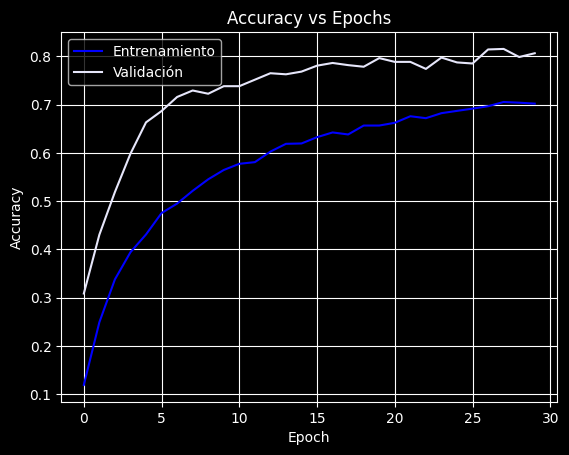

In [ ]:
plt.figure()
plt.plot(history_tl11.history['accuracy'], label='Entrenamiento',color='blue')
plt.plot(history_tl11.history['val_accuracy'], label='Validación',color='lavender')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epochs')
plt.legend()
plt.grid(True)
plt.show()

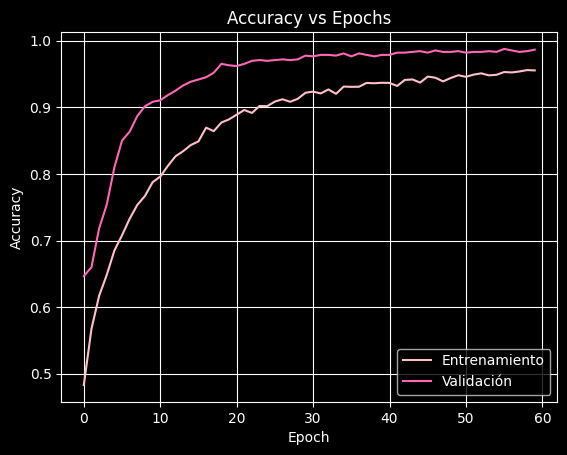

In [ ]:
# Accuracy
plt.figure()
plt.plot(history_ft_11.history['accuracy'], label='Entrenamiento',color='pink')
plt.plot(history_ft_11.history['val_accuracy'], label='Validación',color='hotpink')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epochs')
plt.legend()
plt.grid(True)
plt.show()

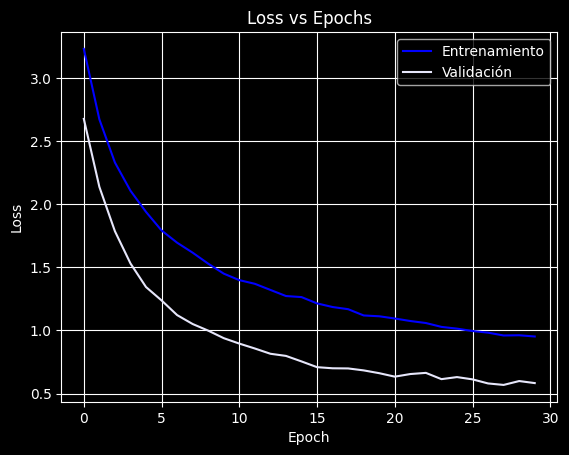

In [ ]:
#Loss
plt.figure()
plt.plot(history_tl11.history['loss'], label='Entrenamiento',color='blue')
plt.plot(history_tl11.history['val_loss'], label='Validación',color='lavender')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.legend()
plt.grid(True)
plt.show()

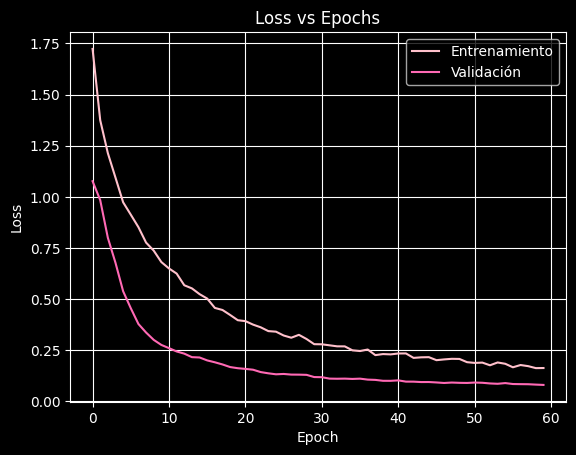

In [ ]:
#Loss
plt.figure()
plt.plot(history_ft_11.history['loss'], label='Entrenamiento',color='pink')
plt.plot(history_ft_11.history['val_loss'], label='Validación',color='hotpink')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.legend()
plt.grid(True)
plt.show()

28/28 ━━━━━━━━━━━━━━━━━━━━ 19s 570ms/step
                 precision    recall  f1-score   support

 letra_ _000000       0.94      1.00      0.97        29
 letra_#_001111       1.00      1.00      1.00        29
 letra_+_011010       0.97      1.00      0.98        29
 letra_-_001001       1.00      0.97      0.98        29
 letra_._001000       1.00      1.00      1.00        29
 letra_=_011011       0.97      1.00      0.98        29
 letra_a_100000       1.00      1.00      1.00        29
 letra_b_110000       1.00      0.97      0.98        29
 letra_c_100100       1.00      1.00      1.00        29
 letra_d_100110       0.97      1.00      0.98        29
 letra_e_100010       1.00      1.00      1.00        29
 letra_f_110100       1.00      1.00      1.00        29
 letra_g_110110       1.00      0.97      0.98        29
 letra_h_110010       0.97      1.00      0.98        29
 letra_i_010100       0.97      1.00      0.98        29
 letra_j_010110       1.00      1.00      1.0

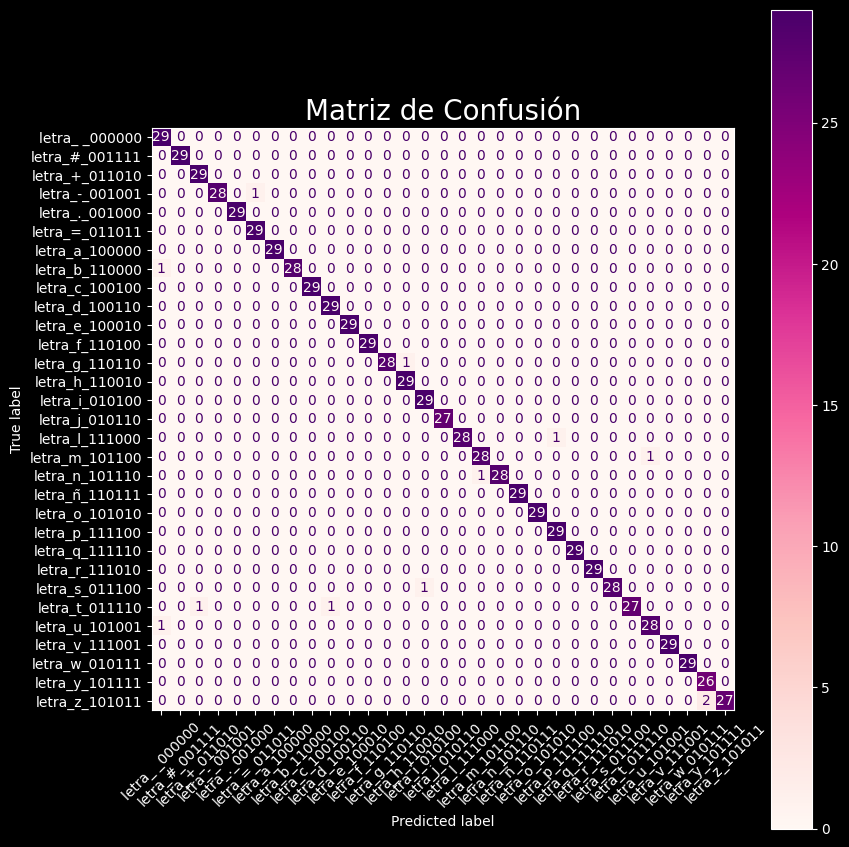

In [ ]:
val_gen2.reset()
y_pred_probs = model11.predict(val_gen2, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)


y_true = val_gen2.classes
class_names = list(val_gen2.class_indices.keys())
print(classification_report(y_true, y_pred, target_names=class_names))


cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(9, 9))
disp.plot(ax=ax, cmap='RdPu', xticks_rotation=45, colorbar=True)

plt.title("Matriz de Confusión", fontsize=20)
plt.tight_layout()
plt.show()